<a href="https://colab.research.google.com/github/jabediqbal101-cmd/Machine-Learning-projects/blob/master/customer%20churn/Telco-Customer-Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")




In [4]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
df['Churn'].value_counts()
df.describe()




   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Imbalance check

In [9]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [10]:
df['TotalCharges'].unique()[:20]


array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [11]:
df['TotalCharges'].dtype

dtype('O')

In [12]:
df[df['TotalCharges'].str.strip() == ' ']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [13]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

see the 11 row of nan value

In [14]:
invalid_totalcharges = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
).isnull()

df[invalid_totalcharges]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [15]:
df.loc[invalid_totalcharges, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [16]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [17]:
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

In [18]:
df['TotalCharges'].isnull().sum()

np.int64(0)

DUPLICATE CATAGORICAL VALUE CHECKING

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn
['No' 'Yes']


In [21]:
for col in df.select_dtypes(include='object').columns:
    print(col, "→", df[col].nunique())

customerID → 7043
gender → 2
Partner → 2
Dependents → 2
PhoneService → 2
MultipleLines → 3
InternetService → 3
OnlineSecurity → 3
OnlineBackup → 3
DeviceProtection → 3
TechSupport → 3
StreamingTV → 3
StreamingMovies → 3
Contract → 3
PaperlessBilling → 2
PaymentMethod → 4
Churn → 2


NMERICAL COLUMN CHECK

In [24]:
df.select_dtypes(include='number').columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

FINDING IMPOSSIBLE VALUE LIKE (-)

In [23]:
for col in df.select_dtypes(include='number').columns:
    print(f"\n{col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("Unique:", df[col].nunique())


SeniorCitizen
Min: 0
Max: 1
Unique: 2

tenure
Min: 0
Max: 72
Unique: 73

MonthlyCharges
Min: 18.25
Max: 118.75
Unique: 1585

TotalCharges
Min: 0.0
Max: 8684.8
Unique: 6531


**EDA**

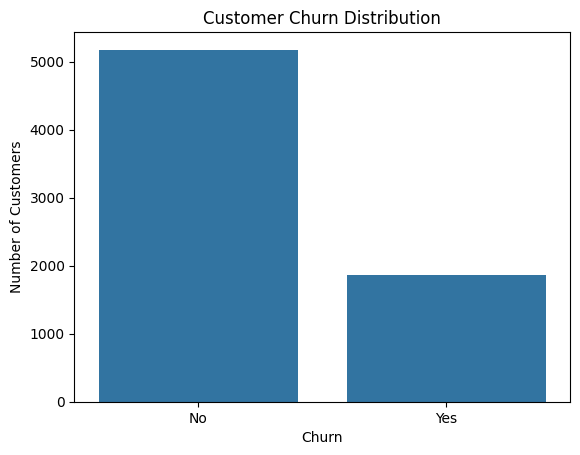

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [26]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [27]:
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_pct)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Churn vs numerical featurs

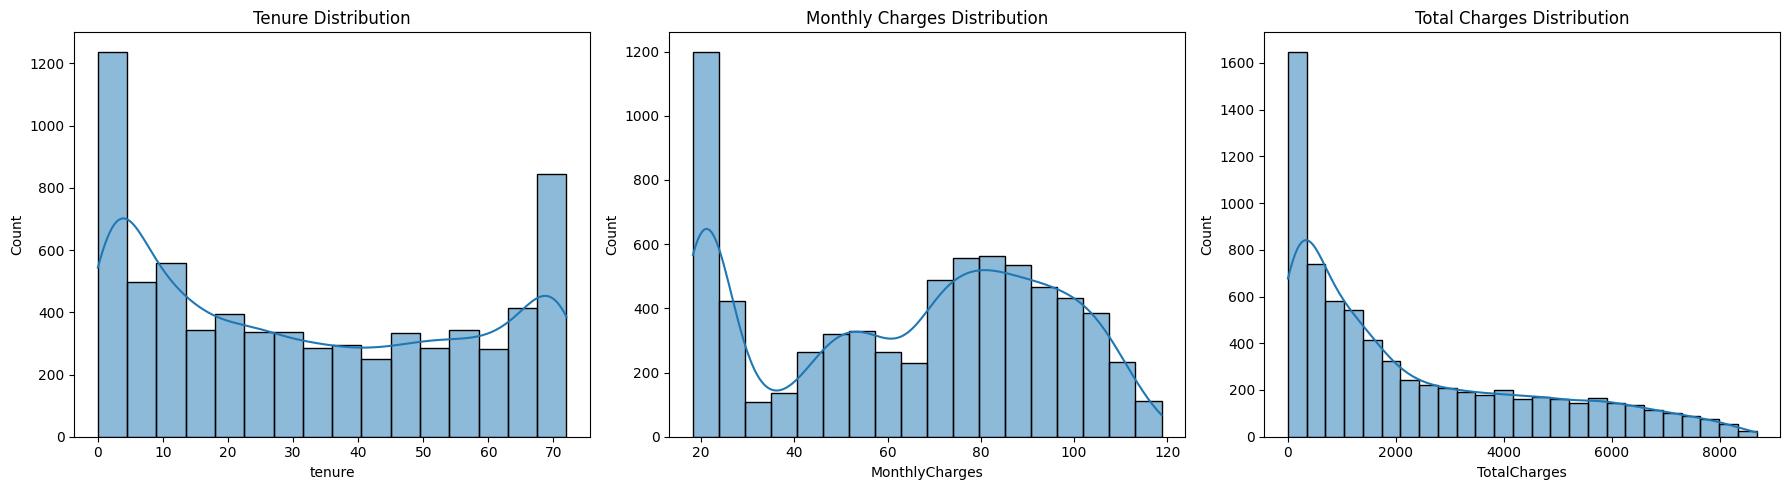

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], kde=True, ax=axes[0])
axes[0].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2])
axes[2].set_title('Total Charges Distribution')

plt.tight_layout()
plt.show()

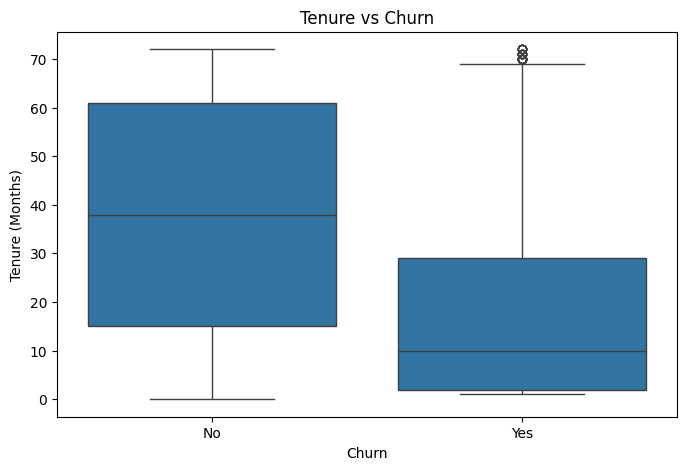

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

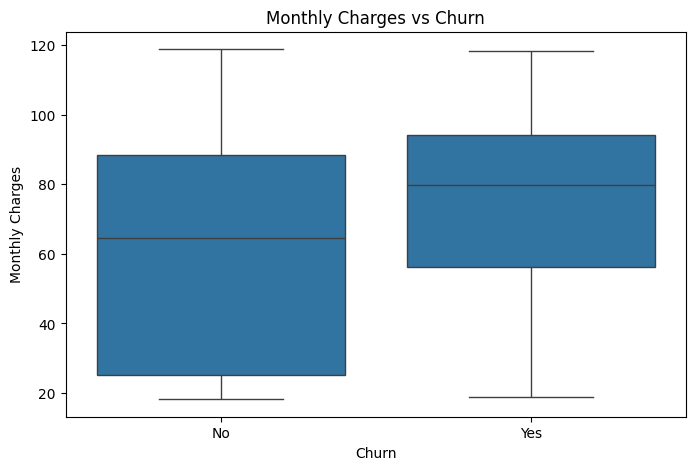

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

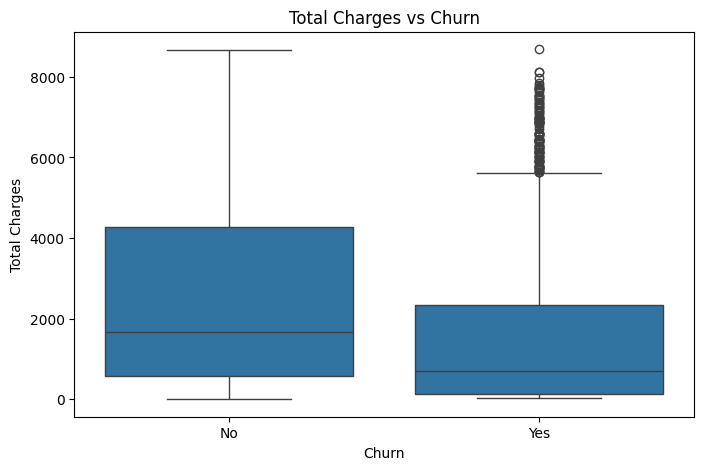

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='TotalCharges')

plt.title('Total Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.show()

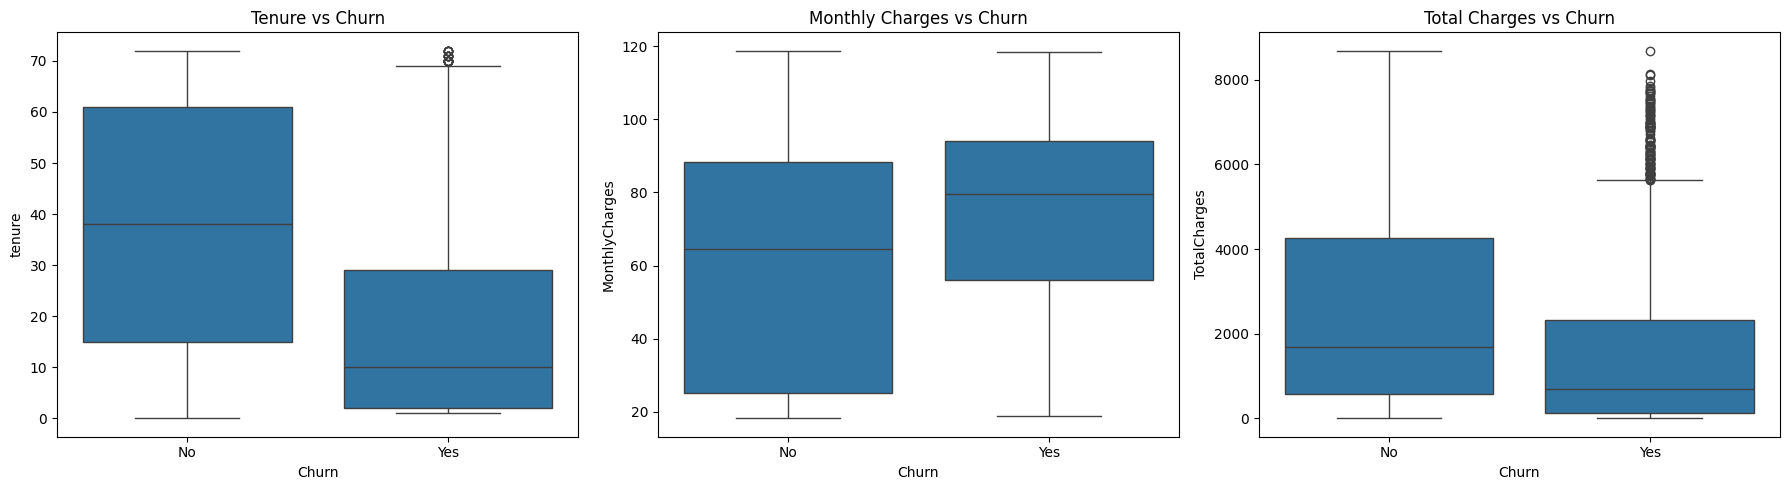

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Tenure vs Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2])
axes[2].set_title('Total Charges vs Churn')

plt.tight_layout()
plt.show()

churn vs catagorical featurs(contract , internetservice , payment method)

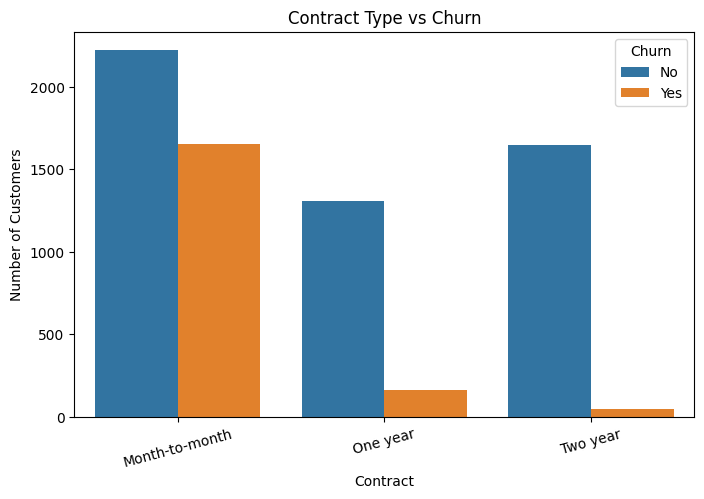

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Contract Type vs Churn')
plt.xlabel('Contract')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

In [35]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


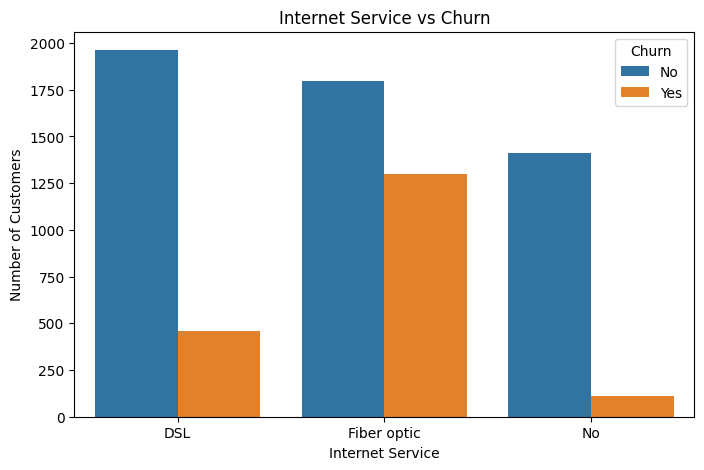

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

In [37]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


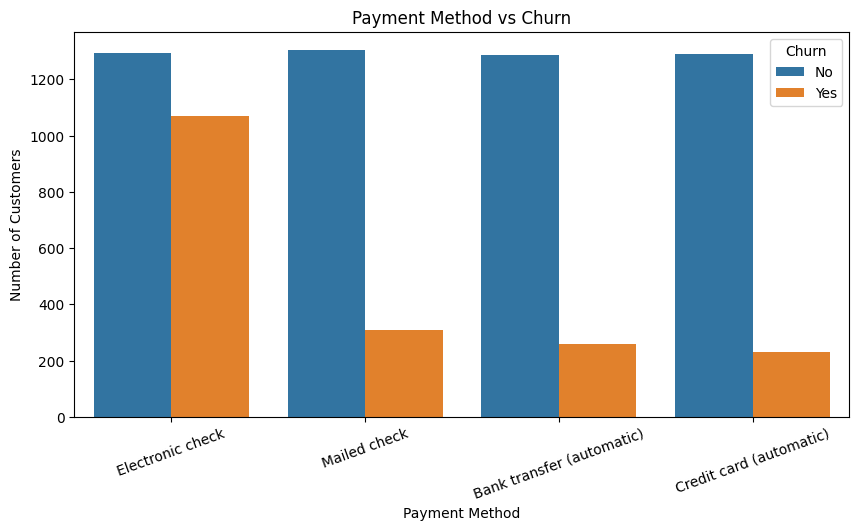

In [38]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

In [39]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

print(payment_churn.round(2))

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


cross terbulation

In [40]:
pd.crosstab(
    df['PaymentMethod'],
    df['Contract'],
    normalize='index'
) * 100

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),38.147668,25.323834,36.528497
Credit card (automatic),35.676741,26.149803,38.173456
Electronic check,78.224101,14.672304,7.103594
Mailed check,55.397022,20.905707,23.697270


In [41]:
pd.crosstab(
    df['InternetService'],
    df['Contract'],
    normalize='index'
) * 100

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,50.516316,23.543990,25.939694
Fiber optic,68.733850,17.409561,13.856589
No,34.338139,23.853211,41.808650


In [42]:
df.groupby('InternetService')['MonthlyCharges'].mean()

,MonthlyCharges
InternetService,
DSL,58.102169
Fiber optic,91.500129
No,21.079194


In [43]:
pd.crosstab(
    df['InternetService'],
    df['TechSupport'],
    normalize='index'
) * 100

TechSupport,No,No internet service,Yes
InternetService,,,
DSL,51.342420,0.0,48.657580
Fiber optic,72.028424,0.0,27.971576
No,0.000000,100.0,0.000000
